# 📋 Config Quick Reference

Diese Zelle zeigt die wichtigsten Parameter aus `FIT_python/config.py` zum schnellen Nachschlagen:

## 🔧 Haupt-Parameter
- **EXPERIMENT_NAME**: `fit_notebook_final` (via `FIT_EXPERIMENT_NAME` env var)
- **GLOBAL_RANDOM_SEED**: `99`
- **TEST_SIZE**: `0.3` (30% Test, 70% Train)
- **NUM_FOLDS**: `5` (für Cross-Validation)
- **GROUP_COL**: `individual_id`
- **STRATIFY_COL**: `sex`

## 📁 Pfad-Struktur
```
EXPERIMENT_ROOT/                      # results/fit_notebook_final/
├── data/
│   ├── cleaned/                      # cfg.CLEANED_DIR
│   └── splits/                       # cfg.SPLITS_DIR
├── dataprocessing/                   # cfg.PATHS["dataprocessing"]
│   └── <species>/
│       ├── figures/
│       └── tables/
├── sex_modelling/                    # cfg.PATHS["sex_modelling"]
│   └── <species>/
│       ├── models/
│       ├── figures/
│       └── tables/
└── individual_id/                    # cfg.PATHS["individual_id"]
    └── <species>/
        ├── master_pairs.csv
        ├── figures/
        └── tables/
```

## 🎨 Farben & Mappings
- **Sex Mapping**: `{0: "Female", 1: "Male", "f": "Female", "m": "Male"}`
- **Sex Colors**: `Female: #800000` (Rot), `Male: #000080` (Blau)
- **Figure DPI**: `300` (Standard für alle Plots)

## 🔬 Pipeline-Defaults
- **Outlier Handling**: `clip` (Quantile: 0.01-0.99)
- **Scaler**: `standard` (StandardScaler)
- **Dimensionality Reduction**: `pca` (n_components=2) oder `umap`
- **Sex Model Metric**: `balanced_accuracy`

## 🐾 Spezies
```python
SPECIES_MODEL_MAP = {
    "panthera_tigris_altaica": "amur_tiger",
    "panthera_tigris_tigris": "bengal_tiger",
    "acinonyx_jubatus": "cheetah",
    "lutra_lutra": "eurasian_otter",
    "tapirus_terrestris": "lowlandtapir",
    "puma_concolor": "mountain_lion",
    "ceratotherium_simum": "white_rhino",
}
```

**Hinweis**: Vollständige Config in [src/FIT_python/config.py](../src/FIT_python/config.py)

Introduction and general goal of this study:
The Footprint Identification Technique (FIT) is a method used to identify individual animals based on their footprints. It also enables the extraction and modeling of additional information such as the sex of the animal that left the footprint.
FIT is currently available as a free add-in for the JMP statistical software and has been custom-tailored for several endangered species. The aim of this dissertation was to establish FIT for the Eurasian otter and benchmark its classification capabilities against those previously published for other species.
This initial analysis was conducted using JMP. However, throughout the workflow, several limitations became evident—particularly regarding automation capabilities for experiments involving modified workflows and the reproducibility of annotated images.
Due to these limitations, the decision was made to transfer the methodology to a Python package, which will be open source and publicly available once the results are published.
The aim of this package is to
1.	replicate the original workflow and analyses of the JMP add-in
2.	optimize the approach for automation
3.	provide flexibility in terms of methodological components and explore whether modifications at various analysis stages lead to improved FIT models.
Although the main aim remained to develop this technique for Eurasian otters all experiments where conducted on several datasets so that the results for otters where always benchmarked with other established species. The following paragraph describes the methodology and the graphs and tables generated at each step.



In [ ]:
from pathlib import Path
import sys, importlib
import os
import shutil

# ---------------------------------------------------------------------
# 1. Project Root
# ---------------------------------------------------------------------
# Für Notebooks: gehe eine Ebene hoch (von notebooks -> Projektwurzel)
if "__file__" in globals():
    root = Path(__file__).resolve().parent.parent
else:
    root = Path().resolve().parent

# Quellcode einbinden
src = root / "src"
sys.path.insert(0, str(src))

# ---------------------------------------------------------------------
# 2. Set Experiment Name BEFORE importing config
# ---------------------------------------------------------------------
os.environ["FIT_EXPERIMENT_NAME"] = "fit_notebook_final_2026_123"

# ---------------------------------------------------------------------
# 3. Import config (setzt nun results/<experiment_name>/ als Root)
# ---------------------------------------------------------------------
import FIT_python.config as cfg
importlib.reload(cfg)  # recompute paths after import

# ---------------------------------------------------------------------
# 4. Experiment Directory
# ---------------------------------------------------------------------
EXP_DIR = cfg.EXPERIMENT_ROOT
EXP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", root)
print("Experiment directory:", EXP_DIR)
print("RAW data directory:", cfg.RAW_DIR)

# ---------------------------------------------------------------------
# 5. Cache-Ordner löschen (alle __pycache__ unterhalb von DATA_DIR)
# ---------------------------------------------------------------------
for pycache in cfg.DATA_DIR.rglob("__pycache__"):
    shutil.rmtree(pycache)
    print(f"🗑 Cache entfernt: {pycache}")


Project root directory: C:\otter_fit\FIT_package
Experiment directory: c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026
RAW data directory: C:\otter_fit\FIT_package\data\raw


Before any train/test splits, a summary table of all analyzed datasets is generated and saved.
Columns:
• Species (Cummonn amen & Latin name) @ gtp you might need a helper dictionary here to consistently right common name and latin name (you can map species labes from the dataset to match style for a research paper)
• No. of footprints [Number of obeseravtions in df • 
No. of known individuals df[individual_id] (after renaming from the original animal coulum check load and split utils)

 No. of trails ( count df[“trails].unique
• No. of measurements ( count number of feature colums Measurements consist of any columns beginning with “V”, “Area”, “dist”, “ang” or “T”, depending on the dataset. Use existing data-loading scripts and feature definitions where possible. Be flexible for groß und kleinschreibung depindig whether data sanatize is already conducted here or not)


In [2]:
from FIT_python.data_split_and_summary.data_import_wrapper import DataImportWrapper
from FIT_python import config as cfg

# Clean all datasets and generate correlation plots
# Note: Correlation plots are automatically saved to:
#   <EXPERIMENT_ROOT>/dataprocessing/<species>/figures/feature_correlations/
wrapper = DataImportWrapper()
result = wrapper.clean_all(generate_histograms=False)

if result == 0:
    print("\n✅ All datasets cleaned and correlation plots saved successfully")
    print(f"📊 Correlation plots location: {cfg.PATHS['dataprocessing']}/<species>/figures/feature_correlations/")
else:
    print("\n⚠️ Some issues occurred during cleaning - check warnings above")

Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned cheetah: shape=(781, 141)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned White_Rhino: shape=(1273, 117)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[SUCCESS] clean_all completed.

✅ All dat

### Wichtige Hinweise zur Datenaufbereitung

Die `clean_all()` Methode führt folgende Schritte aus:
1. **Lädt Rohdaten** aus `RAW_DIR`
2. **Bereinigt Labels** (Individual IDs, Sex, etc.)
3. **Speichert Parquet-Dateien** in `CLEANED_DIR`
4. **Generiert Correlation-Plots** für jede Spezies (Feature-Gruppen: distance, angle, triangles)

**Robustheit bei fehlenden Features:**
- Falls eine Spezies <2 Features einer Kategorie hat, wird ein Platzhalter angezeigt statt eines Fehlers
- Warnung im Log: `[WARN] correlation plot failed for <species>: ...`
- Plots werden immer gespeichert unter: `<experiment_root>/dataprocessing/<species>/figures/feature_correlations/`

**DPI-Standard:** Alle Plots werden mit **DPI=300** für Publikationsqualität gespeichert.

Overview generation of Datasets in experiment

In [3]:
from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview

# Generate overview with summary statistics for all species
# Note: Last row will contain totals across all species
overview_df = generate_dataset_overview(cfg.RAW_DIR, EXP_DIR/'dataset_overview.parquet', reuse=False)
overview_df

Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Training and Test splits and inference splits
For both sex‐classification and individual‐identification models, the captive dataset of known individuals was randomly divided into training and validation subsets using a script‐based, group‐stratified sampling procedure with a fixed random seed to ensure reproducibility. Stratification guaranteed an even sex ratio across both splits, while grouping by animal prevented any overlap of individuals between training and testset.  Additional Validation folds were created and assigned and later used for hyperparameter optimization.
For the Otters a custom script for generating the folds was used making sure, that dna validated field prints only appeared in the testset, additionally since we had a set of prints in Sand and a set of prints in mud available we made sure that an equal number of individuals of both sexes are present in the testset. Train test splits needs to be executed here as it includes data cleaning steps that otherwise cause errors in the data exploration and visualisations functions that technically come beforehand in the dissertations


Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Splitting datasets:   0%|          | 0/8 [00:00<?, ?it/s]

↪️  Verwende bestehende Splits für amur_tiger
↪️  Verwende bestehende Splits für bengal_tiger
↪️  Verwende bestehende Splits für cheetah
↪️  Verwende bestehende Splits für eurasian_otter
↪️  Verwende bestehende Splits für giant_panda
↪️  Verwende bestehende Splits für lowlandtapir
↪️  Verwende bestehende Splits für mountain_lion
↪️  Verwende bestehende Splits für white_rhino


Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Splits:   0%|          | 0/3 [00:00<?, ?it/s]


[DEBUG] compute_summary called for eurasian_otter/inference, df shape = (81, 214)
[DEBUG] ds_label = eurasian_otter Inference
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['lutra_lutra']
[DEBUG] species_code = lutra lutra
[DEBUG] sex value counts:
sex
Unknown    81
Name: count, dtype: int64
[DEBUG] has_dataorigin = True, dataorigins = ['Fieldprints Portugal']
[DEBUG] dataorigin=Fieldprints Portugal, sex=Female, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] dataorigin=Fieldprints Portugal, sex=Male, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] dataorigin=Fieldprints Portugal, sex=Unknown, subset shape = (81, 214)
[DEBUG]  n_fp=81, n_ind=1, n_tr=8
[DEBUG]   fp_per_ind summary: mean=81.0, sd=0.0
[DEBUG]   tr_per_ind summary: mean=8.0, sd=0.0
[DEBUG] Returning summar

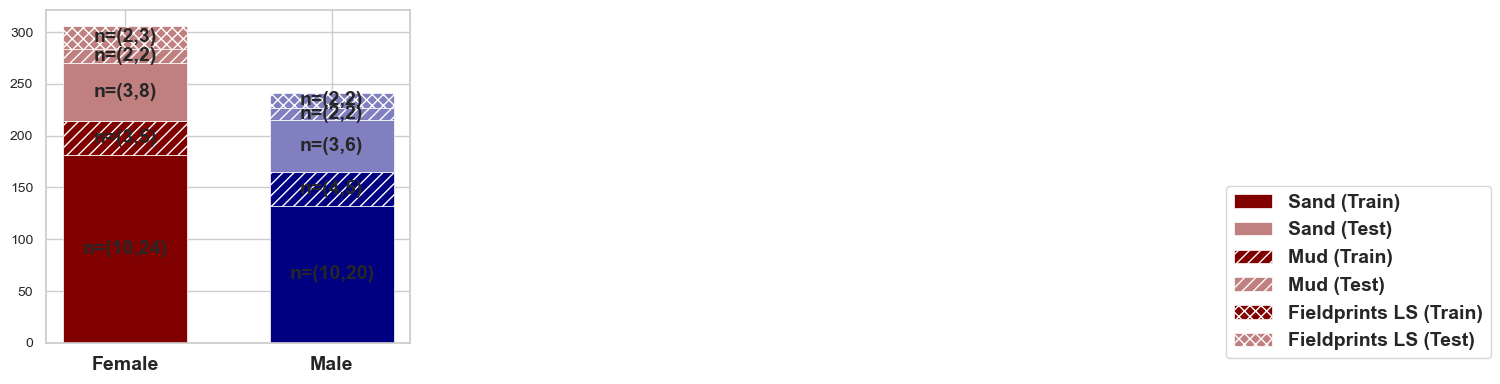

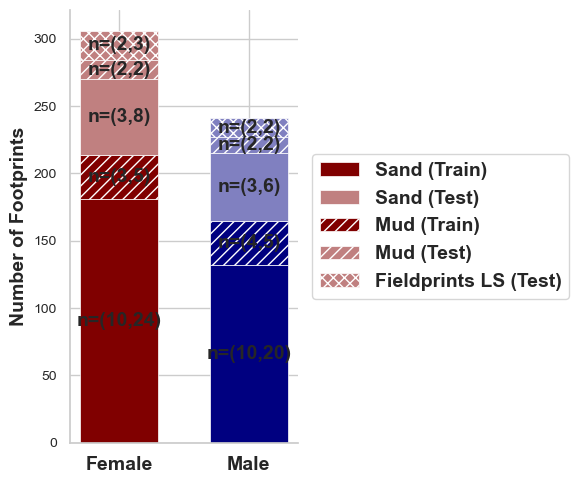

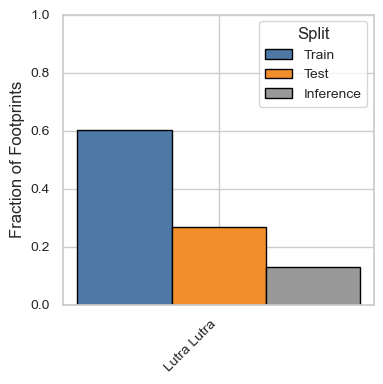

In [4]:
from FIT_python import config
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper

species = "eurasian_otter"
SplitWrapper().split_all(reuse_splits=True)

run_summary(config.SPLITS_DIR / species, species)


Data Exploration (This step is performed exclusively on the otter data to keep the number of plots manageable.)
With over two hundred measurements extracted from just 11 unique landmarks, we anticipate high correlation among features. Previous FIT publications have shown that using many measurements aids individual identification. However, when the number of measurements far exceeds the number of landmarks, strong correlations between individual measurements emerge.
1.	A correlation matrix (Distances, Angles, Areas) is visualized (see “Correlation Matrix for Eurasian Otters”).
2.	We examine the top four univariate features with the highest separation power for the targets “sex” and “individual_id” on the full otter dataset.
3.	We generate two supervised UMAP embeddings—for “sex” and for “individual_id”—using fivefold cross-validation. Note that these embeddings are for visualization only; all modeling steps described later adhere to a stricter split regime.


In [5]:
from FIT_python.utils.paths import get_species_paths
from FIT_python.Visualisations.plots_utils import plot_feature_correlation_matrix, plot_individual_boxplots_2x1
from FIT_python import config as cfg
import pandas as pd
from FIT_python import config as cfg
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols


otter_df = pd.read_parquet(cfg.CLEANED_DIR / "Eurasian_Otter.parquet")


species = "eurasian_otter"

# get paths managed by the config (e.g. in dataprocessing/eurasian_otter/figures)
paths = get_species_paths(species, section="dataprocessing")
fig_dir = paths["figures"]          # directory already created by get_species_paths
fig_path = plot_feature_correlation_matrix(otter_df, fig_dir)  # figure saved here

feature_cols = get_feature_cols(otter_df)
# --- Aufruf ---
plot_individual_boxplots_2x1(
    df=otter_df,
    fig_dir=fig_dir,
    filename="individual_boxplots_2x1.png",
    feature_cols=feature_cols
)


[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[CAPTION] Boxplots of ['dist10_14', 't2_3_5'] grouped by individual


(WindowsPath('c:/otter_fit/FIT_package/notebooks/results/fit_notebook_final_2026/dataprocessing/eurasian_otter/figures/individual_boxplots_2x1.png'),
 ['dist10_14', 't2_3_5'])

Visualisierung mit Umap alle Otter

c:\Users\Frede\miniconda3\envs\FIT_python_conda_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Frede\AppData\Local\Temp\ipykernel_9988\3002377724.py:88: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_9988\3002377724.py:88: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_9988\3002377724.py:88: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the futu

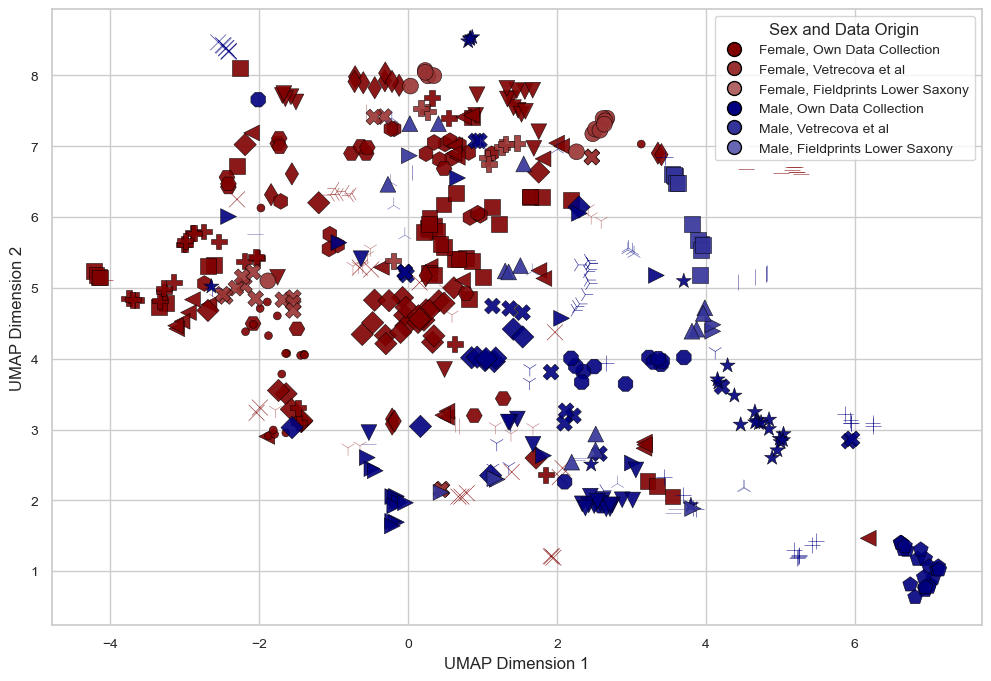

✅ UMAP plot saved: c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\dataprocessing\eurasian_otter\figures\umap_individuals_sex_origin_shaded_by_dataset.png


In [6]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
from matplotlib.lines import Line2D
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.utils.paths import get_species_paths
from FIT_python import config as cfg


# Hilfsfunktion für Farbaufhellung (aus config.py)
def lighten_color(color: str, amount: float) -> str:
    """Lighten a hex color by the given amount (0.0 = no change, 1.0 = white)."""
    color = color.lstrip("#")
    r = int(color[0:2], 16) / 255
    g = int(color[2:4], 16) / 255
    b = int(color[4:6], 16) / 255
    r = round((r + (1 - r) * amount) * 255)
    g = round((g + (1 - g) * amount) * 255)
    b = round((b + (1 - b) * amount) * 255)
    return f"#{r:02x}{g:02x}{b:02x}"


# --------------------------------
# Embedding erzeugen
# --------------------------------
# Nur gewünschte Dataorigins filtern
otter_df = otter_df[otter_df['dataorigin'].isin([
    'Vetrecova et al', 'Own Data Collection', 'Fieldprints Lower Saxony'
])]
species = "eurasian_otter"

# Features bestimmen und numerisch umwandeln
features = get_feature_cols(otter_df)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)

# supervised UMAP mit Individual-ID und festem Seed
dr = DimensionalityReducerTransformer(
    method='umap',
    supervised=True,
    random_state=42    # Seed für Reproduzierbarkeit
)
emb = dr.fit_transform(X, otter_df['individual_id'])

# DataFrame mit Embedding und Metadaten
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=otter_df['sex'].map({'f':'Female', 'F':'Female', 0:'Female',
                                    'm':'Male', 'M':'Male', 1:'Male'}),
    dataorigin=otter_df['dataorigin']
)

# Marker-Liste für viele Individuen
markers = ['o', 's', '^', 'v', '<', '>', 'P', 'X', 'D', '*', '+', 'x', '|', '_',
           '1', '2', '3', '4', '8', 'p', 'H', 'h', 'd', '.', ',']
marker_cycle = itertools.cycle(markers)
unique_individuals = emb_df['individual_id'].unique()
marker_map = {ind: next(marker_cycle) for ind in unique_individuals}

# Farben aus Config verwenden (wie in Boxplots)
sex_colors = cfg.SEX_COLORS  # {"Female": "#800000", "Male": "#000080"}
dataset_shades = cfg.DATASET_COLOR_SHADES  # {"Own Data Collection": 0.0, "Vetrecova et al": 0.2, "Fieldprints Lower Saxony": 0.4}

# Farbpalette erstellen mit dataset-spezifischen Schattierungen
sex_palette = {
    sex: {
        origin: lighten_color(color, dataset_shades[origin])
        for origin in dataset_shades
    }
    for sex, color in sex_colors.items()
    if sex in ["Female", "Male"]
}

# Farbe zuweisen basierend auf Sex und Data Origin
def assign_color(row):
    return sex_palette[row['sex_mapped']][row['dataorigin']]

emb_df['color'] = emb_df.apply(assign_color, axis=1)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    for ind, subgroup in group.groupby('individual_id'):
        ax.scatter(
            subgroup['UMAP1'], subgroup['UMAP2'],
            c=subgroup['color'],
            marker=marker_map[ind],
            s=130,
            alpha=0.9,
            edgecolor='black',
            linewidth=0.4
        )

# Achsenbeschriftungen
ax.set_xlabel("UMAP Dimension 1", fontsize=12)
ax.set_ylabel("UMAP Dimension 2", fontsize=12)

# Legende mit allen Sex/Origin Kombinationen
legend_elements = []
origin_order = list(dataset_shades.keys())
for sex in ["Female", "Male"]:
    for origin in origin_order:
        legend_elements.append(Line2D(
            [0], [0], marker='o', color='w', label=f"{sex}, {origin}",
            markerfacecolor=sex_palette[sex][origin], markersize=10, markeredgecolor='black'
        ))

ax.legend(handles=legend_elements, title="Sex and Data Origin", fontsize=10, loc='best')

# Speichern
species = "eurasian_otter"
fig_dir = get_species_paths(species, section="dataprocessing")["figures"]
fig_path = fig_dir / "umap_individuals_sex_origin_shaded_by_dataset.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ UMAP plot saved: {fig_path}")

Training sex Model

c:\Users\Frede\miniconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\preprocessing\_label.py:302: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  self.y_type_ = type_of_target(y, input_name="y")
c:\Users\Frede\miniconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)
C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\search.py:170: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_all = pd.read_csv(all_csv).apply(pd.to_numeric, errors="ignore")
C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\search.py:171: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explici

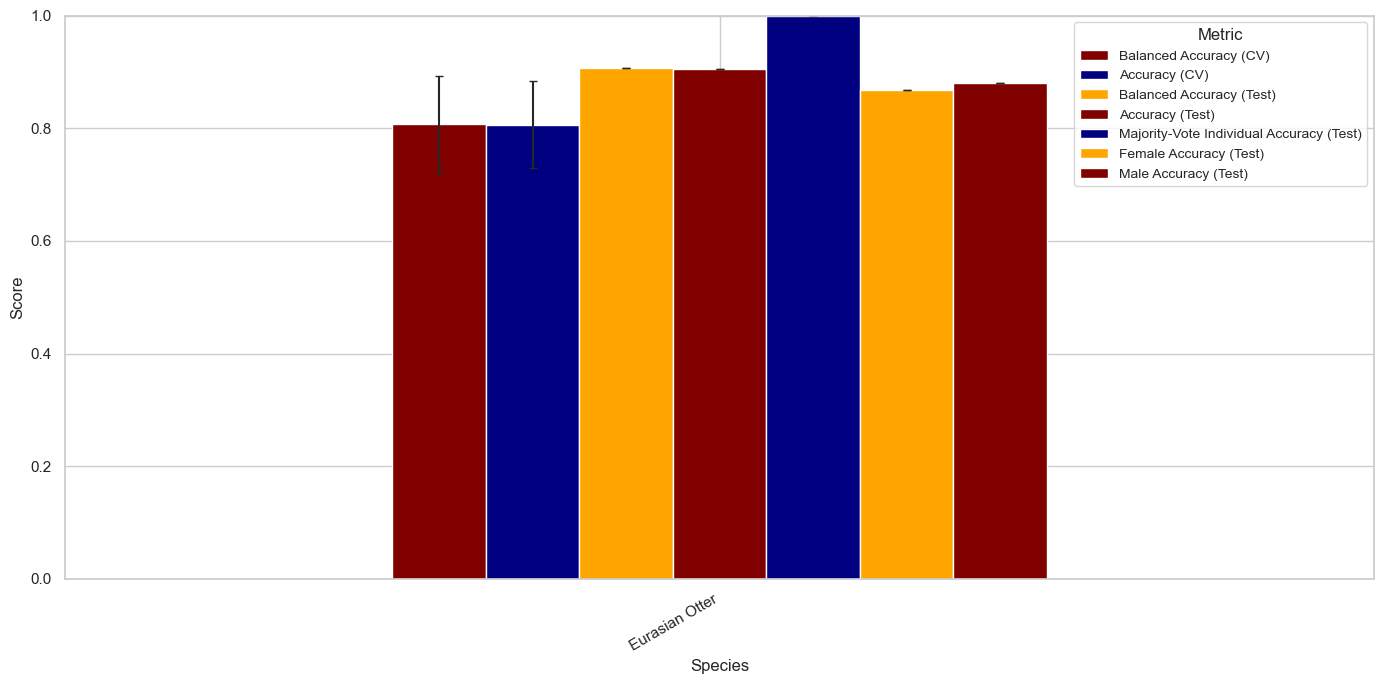

In [7]:
from FIT_python.pipeline_sex.search import (
    run_otter_search_sex,
    run_other_species_search,
    collect_best_metrics
)
import FIT_python.config as cfg

# Hyper‑parameter search (reuses previous CSVs/models if present)
run_otter_search_sex(reuse_results=True)      # Eurasian otter
#run_other_species_search(reuse_results=True)                    # all remaining species

# Summarise the best models across species
summary_df = collect_best_metrics(cfg.PATHS["sex_modelling"])
summary_df.head()

benchmark_df = summary_df

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# (optional) import seaborn as sns; sns.set_style("whitegrid")

# --- run searches / collect results as you already do ---
# summary_df = collect_best_metrics(cfg.PATHS["sex_modelling"])

benchmark_df = summary_df.copy()

# ---------- helpers ----------
def pick(colnames, candidates):
    """Return first existing column from candidates."""
    for c in candidates:
        if c in colnames:
            return c
    return None

cols = set(benchmark_df.columns)

# Canonical label -> possible source columns
canon_map = {
    "Species":                        ["species", "Species"],

    # Test
    "Accuracy (Test)":                ["accuracy_test", "test_accuracy"],
    "Balanced Accuracy (Test)":       ["balanced_test_acc", "test_balanced_accuracy"],
    "Majority-Vote Individual Accuracy (Test)": ["maj_test_pct", "test_majority_accuracy"],
    "Female Accuracy (Test)":         ["female_test_acc"],
    "Male Accuracy (Test)":           ["male_test_acc"],

    # CV means
    "Accuracy (CV)":                  ["mean_cv_accuracy", "mean_test_accuracy", "cv_mean_accuracy"],
    "Balanced Accuracy (CV)":         ["mean_cv_balanced_accuracy", "mean_test_balanced_accuracy", "cv_mean_balanced_accuracy"],
    "Log Loss (CV)":                  ["mean_cv_neg_log_loss", "mean_test_neg_log_loss", "cv_mean_neg_log_loss"],

    # CV std (for error bars)
    "Accuracy (CV) SD":               ["std_cv_accuracy", "std_test_accuracy", "cv_std_accuracy"],
    "Balanced Accuracy (CV) SD":      ["std_cv_balanced_accuracy", "std_test_balanced_accuracy", "cv_std_balanced_accuracy"],
    "Log Loss (CV) SD":               ["std_cv_neg_log_loss", "std_test_neg_log_loss", "cv_std_neg_log_loss"],
}

# Build a renamed dataframe with only the columns we can find
keep = {}
for label, candidates in canon_map.items():
    src = pick(cols, candidates)
    if src is not None:
        keep[label] = benchmark_df[src]

benchmark_df = pd.DataFrame(keep)

# Clean species names
if "Species" in benchmark_df.columns:
    benchmark_df["Species"] = (
        benchmark_df["Species"].astype(str)
        .str.replace("_", " ")
        .str.title()
    )

# Round and sort by Balanced Accuracy (Test) if present
benchmark_df = benchmark_df.round(3)
sort_key = "Balanced Accuracy (Test)" if "Balanced Accuracy (Test)" in benchmark_df.columns else None
if sort_key:
    benchmark_df = benchmark_df.sort_values(by=sort_key, ascending=False)

# ---------------- plotting with error bars on CV metrics ----------------
plot_cols = [c for c in [
    "Balanced Accuracy (CV)",
    "Accuracy (CV)",
    "Balanced Accuracy (Test)",
    "Accuracy (Test)",
    "Majority-Vote Individual Accuracy (Test)",
    "Female Accuracy (Test)",
    "Male Accuracy (Test)",
] if c in benchmark_df.columns]

# yerr DataFrame aligned to plot_cols (zeros where no SD available)
yerr_df = pd.DataFrame(0.0, index=benchmark_df.index, columns=plot_cols)
sd_map = {
    "Balanced Accuracy (CV)": "Balanced Accuracy (CV) SD",
    "Accuracy (CV)": "Accuracy (CV) SD",
    # (Log Loss (CV) isn’t plotted here, add if needed)
}
for mean_col, sd_col in sd_map.items():
    if mean_col in plot_cols and sd_col in benchmark_df.columns:
        yerr_df[mean_col] = benchmark_df[sd_col].to_numpy()

# Output dir
benchmark_dir = Path(cfg.PATHS["sex_modelling"]) / "benchmark_plots"
benchmark_dir.mkdir(parents=True, exist_ok=True)

# Plot
ax = (benchmark_df
      .set_index("Species")[plot_cols]
      .plot(kind="bar", figsize=(14, 7), yerr=yerr_df.T.values, capsize=3))

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Species", fontsize=12)
ax.legend(title="Metric", fontsize=10)
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig(benchmark_dir / "benchmark_summary_best_test_plot.png", dpi=300)
plt.show()




📊 Starte Plotgruppe: DEIN_METRIC_KEY


C:\Users\Frede\AppData\Local\Temp\ipykernel_9988\192525730.py:87: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


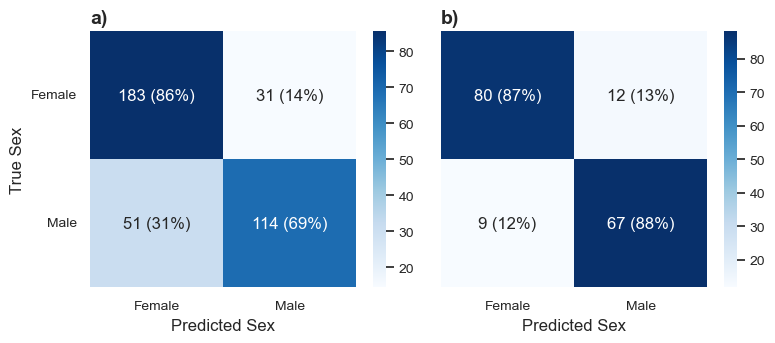

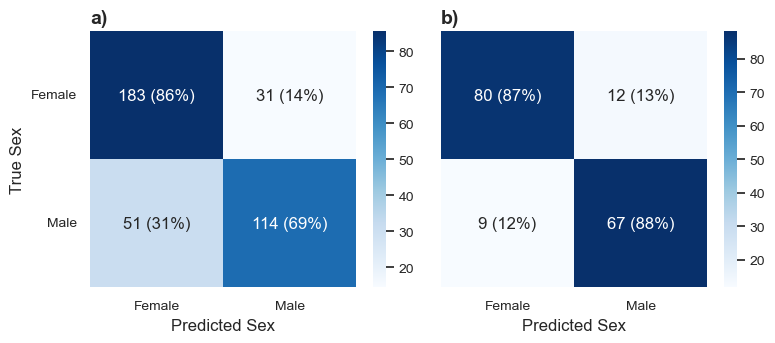

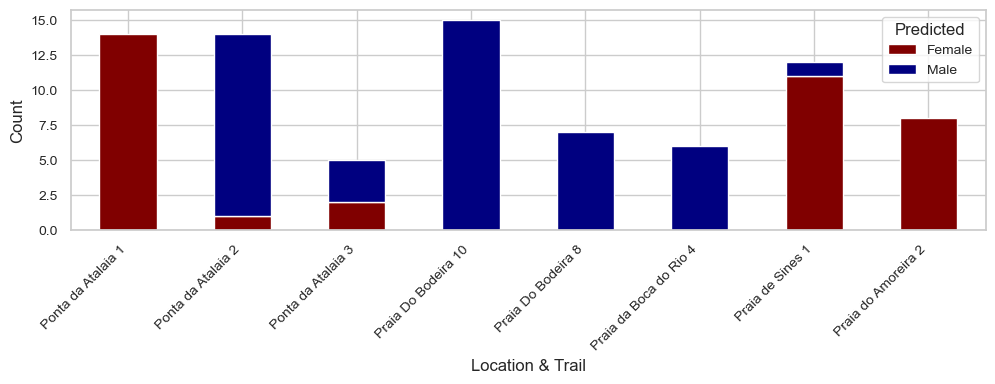

C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(na

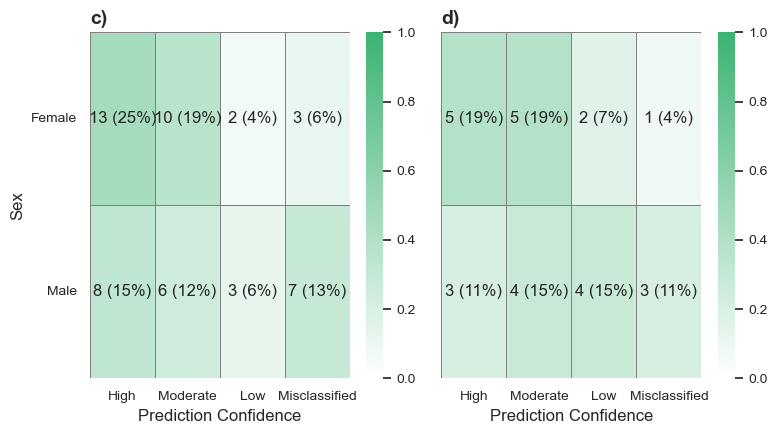

C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(na

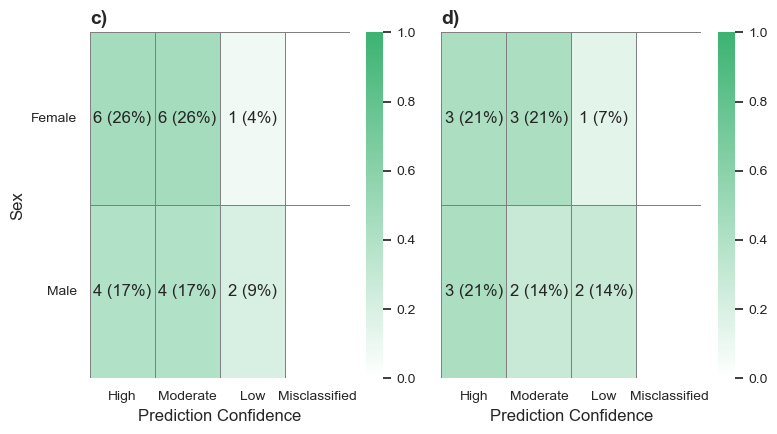

C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


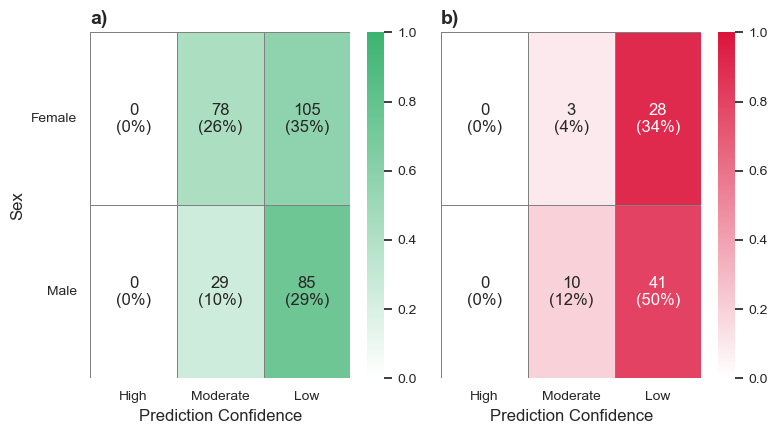

C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


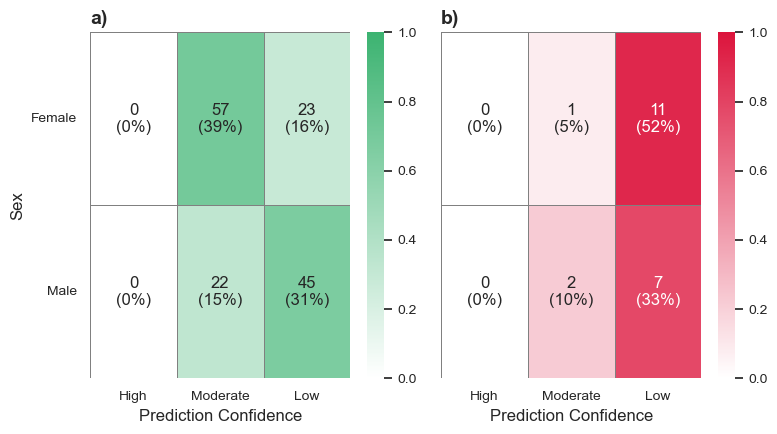

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für balanced_accuracy gespeichert in c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\Sex_plots\balanced_accuracy


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import importlib

from FIT_python import config
from FIT_python.utils import get_species_paths
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    predict_all,
    plot_confusion_and_inference,
    plot_quality_grouped,
    plot_quality_heatmaps,
    plot_individual_probabilities,
    plot_confusion,
    plot_hist_predsex_train_test,
)

# ---------------------------------------------------------------------
# Konfiguration aktualisieren (berücksichtigt FIT_EXPERIMENT_NAME aus vorherigem Block)
# ---------------------------------------------------------------------
importlib.reload(config)

DEFAULT_SPECIES = "eurasian_otter"
sex_mapping = {"F": 0, "M": 1, "f": 0, "m": 1}

BASE_DIR = config.EXPERIMENT_ROOT
SEX_DIR = BASE_DIR / "Sex_plots"
SEX_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Hilfsfunktion: Histogramm der Vorhersagen pro Modell
# ---------------------------------------------------------------------
def plot_histogram_per_model(df, metric_key, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    df_plot = df.copy()
    df_plot["true_label"] = df_plot["sex"].replace(sex_mapping)
    df_plot["split_label"] = df_plot["__split__"].replace({"train": "Train (CV)", "test": "Test"})

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for i, split in enumerate(["train", "test"]):
        df_sub = df_plot[df_plot["__split__"] == split]
        if df_sub.empty:
            continue
        sns.histplot(
            data=df_sub,
            x="pred_sex",
            hue="individual_id",
            multiple="stack",
            bins=10,
            ax=axes[i],
            palette="Set2",
            legend=False,
        )
        axes[i].set_title(f"{split.capitalize()} Set – Prediction Distribution")
        axes[i].set_ylabel("Count")
    axes[1].set_xlabel("Predicted Sex (0=F, 1=M)")
    fig.suptitle(f"Prediction Histogram by Individual – {metric_key}", fontsize=14)
    plt.tight_layout()
    fig.savefig(out_dir / f"prediction_histogram_{metric_key}.png", dpi=300)
    plt.close()

# ---------------------------------------------------------------------
# Hauptschleife über alle gespeicherten Modelle
# ---------------------------------------------------------------------
# Pfad zu allen gespeicherten Modellen des Otters
paths = get_species_paths(DEFAULT_SPECIES)  
# oder explizit: get_species_paths(species=DEFAULT_SPECIES, section="sex_modelling")
models_root = Path(paths["models"])
metric_key = "DEIN_METRIC_KEY"  # <-- hier den gewünschten Ordnernamen/Key eintragen
print(f"\n📊 Starte Plotgruppe: {metric_key}")

metric_key=config.BAYES_REFIT

df_all = predict_all(
    species=DEFAULT_SPECIES,
    metric_key=metric_key,
    prefer_generic=True,
    include_inference=True,
    reuse_csv=False,             # CSVs ggf. neu schreiben
    use_cv_train_predictions=True,
)

if "pred_sex" not in df_all.columns:
    print(f"⚠️ Keine 'pred_sex'-Spalte für {metric_key} – überspringe.")
else:
    df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)

    out_dir = SEX_DIR / metric_key
    out_dir.mkdir(parents=True, exist_ok=True)

    # Plots
    plot_confusion(df_all)
    plot_confusion_and_inference(df_all)
    plot_quality_grouped(df_all)
    plot_quality_heatmaps(df_all)
    plot_individual_probabilities(df_all, out_dir=out_dir)
    plot_hist_predsex_train_test(df_all)
    plot_histogram_per_model(df_all, metric_key, out_dir)

    print(f"✅ Ergebnisse für {metric_key} gespeichert in {out_dir}")


In [10]:
# === Imports ===
import numpy as np
import pandas as pd
from pathlib import Path
import importlib
import time

from FIT_python.pipeline_individual_id.simple_baseline import (
    run_fold_cv,
    get_feature_cols,
)
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import (
    generate_pairwise_comparisons_from_df,
)
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_sex.sex_predict_and_visualisation import predict_all
from FIT_python.pipeline_sex.sex_model_loader import get_sex_model_path  # <-- NEU

# --- Config laden (soft-coded) ---
from FIT_python import config as cfg
importlib.reload(cfg)

# Pfade aus config
base_dir     = cfg.SPLITS_DIR                        # <EXPERIMENT_ROOT>/data/splits
out_base_dir = cfg.PATHS["individual_id"]            # <EXPERIMENT_ROOT>/results/individual_id
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

# Mapping wissenschaftlich -> common aus config (soft-coded)
SPECIES_MODEL_MAP = {k.lower(): v for k, v in cfg.SPECIES_MODEL_MAP.items()}
def to_common_name(name: str) -> str:
    return SPECIES_MODEL_MAP.get((name or "").lower(), name)

# Laufparameter
results = {}
k_range = range(16, 20,2)
selection_methods = ["lasso", "random_forest", "forward"]
sex_flags = [True]  # ggf. [False, True]

# === Neu: globale Sammelliste für alle Spezies/Tags ===
all_master_pairs: list[pd.DataFrame] = []

# === Hauptschleife ===
for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue

    species_raw = sp_dir.name
    species     = to_common_name(species_raw)  # common name für Modelle/Ergebnisse
    print(f"\n##### {species_raw}  →  {species} #####")

    train_path = sp_dir / "train.parquet"
    test_path  = sp_dir / "test.parquet"
    infer_path = sp_dir / "inference.parquet"

    if not train_path.exists() or not test_path.exists():
        print(f"⚠️  Überspringe {species_raw}, da train/test fehlt.")
        continue

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)

    include_inference = False
    if infer_path.exists():
        df_inf = pd.read_parquet(infer_path)
        include_inference = len(df_inf) > 0
    else:
        df_inf = pd.DataFrame()

    print(
        f"📊 Datensatzgrößen – "
        f"Train: {len(df_train)}, Test: {len(df_test)}, "
        f"Inference: {len(df_inf) if include_inference else 0}"
    )

    feature_cols = get_feature_cols(df_train)

    # Species-Output
    out_dir = out_base_dir / species
    out_dir.mkdir(parents=True, exist_ok=True)

    master_pairs: list[pd.DataFrame] = []

    # === Sex-Predictions (OOF für Train; Full-Train für Test/Inference)
    sex_preds = predict_all(
        species=species,                          # common name!
        metric_key=cfg.SEX_PREDICT_METRIC,        # z.B. "balanced_accuracy"
        prefer_generic=False,
        include_inference=include_inference,
        reuse_csv=False,                          # CSV bei Bedarf neu schreiben
        use_cv_train_predictions=True,
    )

    # >>> Kritisch: den korrekten Sex-Model-Pfad SOFT-CODED auflösen
    sex_model_fp = get_sex_model_path(species=species, metric=cfg.SEX_PREDICT_METRIC)
    # z.B.: <EXPERIMENT_ROOT>/results/sex_modelling/<common>/models/<metric>/<common>.joblib
    print("🔗 Sex model:", sex_model_fp)

for fs in selection_methods:
    for k in k_range:
        for use_sex in sex_flags:
            start_time = time.perf_counter()
            tag = f"{fs}_k{k}_{'sex' if use_sex else 'morph'}"

            # 1) CV
            cv_dir = out_dir / tag / "cv_results"
            cv_dir.mkdir(parents=True, exist_ok=True)

            # optional: zentrales k spiegeln
            cfg.CONFIG["pipeline_individual_id"]["pairwise_defaults"]["k_features"] = k

            # <<< NEU: master_fp + korrekte Trail-Spalte >>>
            master_parquet = out_dir / f"{species}_master_pairs.csv"

            summary_cv = run_fold_cv(
                df_train,
                feature_cols,
                sex_predictions=sex_preds,
                fold_col="Fold",              # Deine Splits haben 'Fold'
                trail_col="Trail",            # <<< WICHTIG: Großes T!
                out_dir=cv_dir,
                selection_method=fs,
                k_features=k,
                scaler_methods="standard",
                use_sexmodel_prediction=use_sex,
                sexmodel_path=sex_model_fp,
                reuse_summary=False,          # beim ersten Mal sicher neu schreiben
                tag=tag,                      # <<< fürs Master-Parquet
                master_fp=master_parquet,     # <<< CV-Paare landen direkt im Master
                overwrite=False,
            )
            print(f"CV fertig: {species} – {tag}. CV-Pairs: {len(summary_cv):,}")

            # CV-Paare (zur Sicherheit) auch aus all_folds.csv einsammeln
            cv_pairs_fp = cv_dir / "all_folds.csv"
            if cv_pairs_fp.exists():
                cv_pairs = pd.read_csv(cv_pairs_fp)
                cv_pairs["origin"] = "cv"
                cv_pairs["tag"] = tag
                cv_pairs["species"] = species
            else:
                # falls reuse_summary True war und keine Datei -> fallback auf Rückgabewert
                cv_pairs = summary_cv.copy()
                if not cv_pairs.empty:
                    cv_pairs["origin"] = "cv"
                    cv_pairs["tag"] = tag
                    cv_pairs["species"] = species

            # 2) Test-Paare
            pairs_dir = out_dir / tag / "test_pairs"
            pairs_dir.mkdir(parents=True, exist_ok=True)

            comps_test, _ = generate_pairwise_comparisons_from_df(
                df_test, strategy="select", evaluation=True, subsample=False, fold_col="Fold", trail_col="Trail"
            )

            try:
                res_df = DistanceBaseline.run(
                    train_df=df_train,
                    val_comparisons=comps_test,
                    val_df=df_test,
                    feature_cols=feature_cols,
                    selection_method=fs,
                    reducers=["lda"],
                    n_components=2,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    n_jobs=-1,
                    sexmodel_path=sex_model_fp,
                )
            except TypeError:
                res_df = DistanceBaseline.run(
                    train_df=df_train,
                    val_comparisons=comps_test,
                    val_df=df_test,
                    feature_cols=feature_cols,
                    selection_method=fs,
                    reducers=["lda"],
                    n_components=2,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    n_jobs=-1,
                )

            out_csv = pairs_dir / f"{species}_pairs.csv"
            res_df.to_csv(out_csv, index=False)
            runtime_s = time.perf_counter() - start_time
            print(f"Test-Paare gespeichert: {out_csv} (n={len(res_df):,}) in {runtime_s:,.1f}s")

            test_pairs = res_df.copy()
            test_pairs["origin"] = "test"
            test_pairs["tag"] = tag
            test_pairs["runtime_s"] = runtime_s
            test_pairs["species"] = species

            # alles in die in-memory-Liste für CSV-Master
            if not cv_pairs.empty:
                cv_pairs["runtime_s"] = runtime_s
                master_pairs.append(cv_pairs)
            master_pairs.append(test_pairs)

            results.setdefault(species, []).append({
                "tag": tag,
                "cv_summary": summary_cv,   # enthält die CV-Paare (falls geschrieben)
                "test_pairs": res_df,
                "runtime_s": runtime_s,
            })


    # --- Master je Spezies (CSV) + in globale Liste aufnehmen ---
    if master_pairs:
        species_master_df = pd.concat(master_pairs, ignore_index=True)
        species_master_fp = out_dir / f"{species}_master_pairs.csv"
        species_master_df.to_csv(species_master_fp, index=False)
        print(f"💾 Spezies-Master gespeichert: {species_master_fp}")
        all_master_pairs.append(species_master_df)

# --- Eine globale Masterdatei (alle Spezies, alle Tags, CV+Test) ---
if all_master_pairs:
    global_master_df = pd.concat(all_master_pairs, ignore_index=True)
    global_master_fp = out_base_dir / "ALL_species_master_pairs.csv"
    global_master_df.to_csv(global_master_fp, index=False)
    print(f"\n🎯 Globaler Master gespeichert: {global_master_fp}")

print("\n✅ Analysen für alle Spezies abgeschlossen.")


✅ Using base_dir: c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\data\splits
✅ Saving results to: c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\individual_id

##### amur_tiger  →  amur_tiger #####
📊 Datensatzgrößen – Train: 484, Test: 121, Inference: 0


FileNotFoundError: No model found at c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\sex_modelling\amur_tiger\models\balanced_accuracy\amur_tiger.joblib

In [ ]:
# %% [markdown]
# --- Fold-Nachtrag für alle Spezies-Master-Pairs ---
# Liest alle *_master_pairs.csv, ergänzt fold-Infos aus train.parquet
# und speichert eine kombinierte CSV "ALL_species_master_pairs_with_folds.csv"

import pandas as pd
from pathlib import Path
from FIT_python import config as cfg

base_dir = cfg.PATHS["individual_id"]
splits_dir = cfg.PATHS["splits"]  # z.B. notebooks/results/fit_notebook_final/data/splits

all_species_dfs = []

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    master_fp = sp_dir / f"{species}_master_pairs.csv"
    if not master_fp.exists():
        print(f"⚠️ {species}: Master-Pairs fehlt, überspringe")
        continue

    df_pairs = pd.read_csv(master_fp)
    if "species" not in df_pairs.columns:
        df_pairs["species"] = species

    # Falls fold-Spalte existiert -> normalisieren
    if "fold" not in df_pairs.columns:
        df_pairs["fold"] = pd.NA

    # Nur ergänzen, wenn origin != test und fold NaN ist
    mask_missing = df_pairs["fold"].isna() & (df_pairs.get("origin") != "test")
    if mask_missing.any():
        train_fp = Path(splits_dir) / species / "train.parquet"
        if train_fp.exists():
            df_train = pd.read_parquet(train_fp)
            # sicherstellen, dass trail_id und fold drin sind
            if "trail_id" in df_train.columns and "fold" in df_train.columns:
                fold_map = df_train.set_index("trail_id")["fold"].to_dict()

                def get_fold(row):
                    # Trails A und B im Fold-Mapping prüfen
                    fa = fold_map.get(row["trail_a_id"])
                    fb = fold_map.get(row["trail_b_id"])
                    return fa if pd.notna(fa) else fb

                df_pairs.loc[mask_missing, "fold"] = df_pairs.loc[mask_missing].apply(get_fold, axis=1)
                print(f"✅ {species}: {mask_missing.sum()} folds ergänzt")
            else:
                print(f"⚠️ {species}: train.parquet ohne 'trail_id'/'fold'")
        else:
            print(f"⚠️ {species}: train.parquet fehlt")

    all_species_dfs.append(df_pairs)

# --- Kombinierte Datei ---
if all_species_dfs:
    df_all = pd.concat(all_species_dfs, ignore_index=True)
    out_fp = base_dir / "ALL_species_master_pairs_with_folds.csv"
    df_all.to_csv(out_fp, index=False)
    print(f"\n🎯 Globale Datei gespeichert: {out_fp} ({len(df_all):,} Zeilen)")
else:
    print("⚠️ Keine Master-Pairs geladen")


#Basline FIT modelbassiert

In [ ]:
# %% [markdown]
# Benchmark LDA with (a) SelectKBest(mutual_info) and (b) PCA(98%) per species,
# now reading the SINGLE combined file:
#   PATHS["individual_id"]/ALL_species_master_pairs_with_folds.csv
# Fallback: per-species CSVs if the combined file is missing.
# Robust handling of 'fold' (case-insensitive -> 'fold').

# %%
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

# --- Config laden ---
from FIT_python import config as cfg

# =================== Ausgabe-Optionen ===================
WRITE_PER_TAG = False          # (deaktiviert) per-Tag-Dateien
WRITE_PER_SPECIES = True       # je Spezies Ergebnisdatei (Parquet)
WRITE_GLOBAL = True            # globale Benchmark-Datei schreiben
GLOBAL_FMT = "csv"             # "parquet" oder "csv"
# =======================================================

# --- Pfade ---
base_dir = cfg.PATHS["individual_id"]
base_dir.mkdir(parents=True, exist_ok=True)
GLOBAL_MASTER = base_dir / "ALL_species_master_pairs.csv"
print("✅ Using combined master (if present):", GLOBAL_MASTER.resolve())

# --- Hilfsfunktionen ---
def to01(v):
    """Robustes Mapping auf {0,1} für same_individual."""
    if pd.isna(v):
        return np.nan
    if isinstance(v, (bool, np.bool_)):
        return int(v)
    s = str(v).strip().lower()
    if s in ("true", "1", "yes", "same"):
        return 1
    return 0

def get_dist_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]

def normalize_fold_column(df: pd.DataFrame) -> pd.DataFrame:
    """Map any case-variant of 'fold' to exact 'fold' (lowercase), once."""
    for col in df.columns:
        if col.lower() == "fold" and col != "fold":
            df = df.rename(columns={col: "fold"})
            break
    return df

def build_pipeline(method: str, dist_cols: list[str]):
    if method == "SelectKBest":
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif)),
            ("model", LinearDiscriminantAnalysis())
        ])
        param_grid = [
            {"select__k": list(range(1, len(dist_cols) + 1)),
             "model__solver": ["svd"], "model__shrinkage": [None]},
            {"select__k": list(range(1, len(dist_cols) + 1)),
             "model__solver": ["lsqr"], "model__shrinkage": [None, 0.1, 0.5, 0.9]},
        ]
    elif method == "PCA98":
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.98, svd_solver="full")),
            ("model", LinearDiscriminantAnalysis())
        ])
        param_grid = [
            {"model__solver": ["svd"], "model__shrinkage": [None]},
            {"model__solver": ["lsqr"], "model__shrinkage": [None, 0.1, 0.5, 0.9]},
        ]
    else:
        raise ValueError(f"Unbekannte Methode: {method}")
    return pipe, param_grid

def load_master_grouped() -> dict[str, pd.DataFrame]:
    """Lädt den kombinierten Master oder fallback auf per-Spezies CSVs. Gibt dict species->df."""
    grouped: dict[str, pd.DataFrame] = {}
    if GLOBAL_MASTER.exists():
        df_all = pd.read_csv(GLOBAL_MASTER)
        df_all = normalize_fold_column(df_all)
        if "species" not in df_all.columns:
            raise KeyError("Combined master fehlt Spalte 'species'.")
        for sp, df_sp in df_all.groupby("species", dropna=False):
            grouped[str(sp)] = df_sp.copy()
        print(f"🎯 Loaded combined master: {len(df_all):,} rows across {len(grouped)} species")
        return grouped

    # Fallback: per-Spezies
    found = 0
    for sp_dir in sorted(base_dir.iterdir()):
        if not sp_dir.is_dir():
            continue
        species = sp_dir.name
        csv_master = sp_dir / f"{species}_master_pairs.csv"
        if not csv_master.exists():
            continue
        df = pd.read_csv(csv_master)
        df = normalize_fold_column(df)
        if "species" not in df.columns:
            df["species"] = species
        grouped[species] = df
        found += 1
        print(f"✅ Loaded {species}: {len(df):,} rows from {csv_master}")
    if not found:
        print("⚠️ Keine Master-Dateien gefunden.")
    else:
        print(f"🎯 Fallback load: {found} species")
    return grouped

# =================== Hauptlauf ===================
species_tables = load_master_grouped()
global_results: list[dict] = []

for species, df_master in species_tables.items():
    # Unknown-Filter robust (IDs in Strings casten)
    for col in ("trail_a_id", "trail_b_id"):
        if col in df_master.columns:
            df_master[col] = df_master[col].astype(str)

    mask_ok = ~(
        df_master.get("trail_a_id", pd.Series("", index=df_master.index)).str.strip().eq("unknown") |
        df_master.get("trail_b_id", pd.Series("", index=df_master.index)).str.strip().eq("unknown")
    )
    df_master = df_master.loc[mask_ok].copy()

    # Distanzfeatures
    dist_cols = get_dist_cols(df_master)
    if not dist_cols:
        print(f"⚠️ Keine Distanz-Features für {species}, überspringe.")
        continue

    # Pflichtspalten prüfen
    if "origin" not in df_master.columns:
        print(f"⚠️ [{species}] Spalte 'origin' fehlt – überspringe Spezies.")
        continue
    if "fold" not in df_master.columns:
        print(f"⚠️ [{species}] Spalte 'fold' fehlt – überspringe Spezies.")
        continue

    # Tag sicherstellen
    if "tag" not in df_master.columns:
        df_master["tag"] = ""

    species_results: list[dict] = []

    # Iteration über Tags (oder "no_tag")
    for tag, df_tag in df_master.groupby("tag", dropna=False):
        tag_str = str(tag) if (tag is not None and str(tag).strip()) else "no_tag"

        # CV / Test trennen und NaNs im Target/Features droppen
        need_cols = dist_cols + ["same_individual"]
        df_cv = df_tag[df_tag["origin"] == "cv"].dropna(subset=need_cols).copy()
        df_tp = df_tag[df_tag["origin"] == "test"].dropna(subset=need_cols).copy()
        if df_cv.empty or df_tp.empty:
            print(f"⚠️ [{species}|{tag_str}] Daten unvollständig (cv={len(df_cv)}, test={len(df_tp)}), überspringe.")
            continue

        # Ziel & Features
        y_cv   = df_cv["same_individual"].map(to01).to_numpy()
        y_test = df_tp["same_individual"].map(to01).to_numpy()
        X_cv   = df_cv[dist_cols].to_numpy()
        X_test = df_tp[dist_cols].to_numpy()

        # Folds für PredefinedSplit
        if df_cv["fold"].isna().all():
            print(f"⚠️ [{species}|{tag_str}] 'fold' ist komplett NaN in CV – überspringe.")
            continue
        folds = pd.to_numeric(df_cv["fold"], errors="coerce").fillna(0).astype(int).to_numpy()
        ps = PredefinedSplit(test_fold=folds)

        # Methoden benchmarken
        for method in ["SelectKBest", "PCA98"]:
            pipe, param_grid = build_pipeline(method, dist_cols)
            gs = GridSearchCV(
                pipe, param_grid,
                scoring="balanced_accuracy",
                cv=ps, refit=True, n_jobs=-1, verbose=0
            )
            gs.fit(X_cv, y_cv)

            # Vorhersagen & Metriken
            y_cv_pred   = gs.predict(X_cv)
            y_test_pred = gs.predict(X_test)

            acc_cv   = balanced_accuracy_score(y_cv,   y_cv_pred)
            acc_test = balanced_accuracy_score(y_test, y_test_pred)
            cm_cv    = confusion_matrix(y_cv,   y_cv_pred, labels=[1, 0])
            cm_test  = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

            result = {
                "species": species,
                "tag": tag_str,
                "method": method,
                "cv_bal_acc": float(np.round(acc_cv, 3)),
                "test_bal_acc": float(np.round(acc_test, 3)),
                "cv_true_same_pred_same": int(cm_cv[0, 0]),
                "cv_true_same_pred_diff": int(cm_cv[0, 1]),
                "cv_true_diff_pred_same": int(cm_cv[1, 0]),
                "cv_true_diff_pred_diff": int(cm_cv[1, 1]),
                "test_true_same_pred_same": int(cm_test[0, 0]),
                "test_true_same_pred_diff": int(cm_test[0, 1]),
                "test_true_diff_pred_same": int(cm_test[1, 0]),
                "test_true_diff_pred_diff": int(cm_test[1, 1]),
            }

            if method == "SelectKBest":
                sel = gs.best_estimator_.named_steps["select"]
                selected = np.array(dist_cols)[sel.get_support()].tolist()
                result["best_k"] = int(sel.k)
                result["selected_features"] = ";".join(map(str, selected))
            else:
                result["pca_n_components"] = int(gs.best_estimator_.named_steps["pca"].n_components_)

            species_results.append(result)

    # --- pro Spezies speichern (optional) ---
    if WRITE_PER_SPECIES and species_results:
        sp_dir = base_dir / species
        sp_dir.mkdir(parents=True, exist_ok=True)
        df_sp = pd.DataFrame(species_results)
        out_fp_sp = sp_dir / "lda_selectk_vs_pca.parquet"
        df_sp.to_parquet(out_fp_sp, index=False, compression="snappy")
        print(f"💾 [{species}] Spezies-Result gespeichert: {out_fp_sp}")

    # --- globale Sammlung füllen ---
    if WRITE_GLOBAL and species_results:
        global_results.extend(species_results)

# --- globale Datei schreiben ---
if WRITE_GLOBAL and global_results:
    df_global = pd.DataFrame(global_results)
    if GLOBAL_FMT.lower() == "parquet":
        out_fp = base_dir / "benchmark_lda_selectk_vs_pca.parquet"
        df_global.to_parquet(out_fp, index=False, compression="snappy")
    else:
        out_fp = base_dir / "benchmark_lda_selectk_vs_pca.csv"
        df_global.to_csv(out_fp, index=False)
    print(f"\n🎯 Globaler Benchmark gespeichert: {out_fp}")
else:
    print("\n⚠️ Keine Ergebnisse zum Schreiben gefunden.")


BAseline ERD 

Grid serach mit novelities

Benchmark best Individual Classification model for all species 

Benchmark improvements erd pipliens

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import compute_erd
from FIT_python import config as cfg

# ======================= Settings =======================
alpha = 0.5  # Gewichtung für Score: S_alpha = alpha*(1-ERD) + (1-alpha)*V
cutoff_range = np.arange(0.4, 4.2, 0.1)
base_metrics = ["euclidean", "manhattan", "cosine", "chebyshev", "canberra", "braycurtis"]
# ========================================================

out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

# ------------------- Dynamische Pfadauflösung für alle Spezies -------------------
# Statt hardcodierter Pfade: durchsuche individual_id Verzeichnis nach master_pairs.csv
master_files = []
for species_dir in sorted(out_base_dir.iterdir()):
    if species_dir.is_dir():
        master_fp = species_dir / f"{species_dir.name}_master_pairs.csv"
        if master_fp.exists():
            master_files.append(master_fp)

if not master_files:
    raise FileNotFoundError(f"❌ Keine Master-Pairs-Dateien gefunden in {out_base_dir}")

print(f"📁 Gefundene Master-Pairs-Dateien: {len(master_files)}")

# ------------------- Laden & Kombinieren -------------------
master_dfs = []
for path_obj in master_files:
    if path_obj.exists():
        df_sp = pd.read_csv(path_obj, low_memory=False)
        master_dfs.append(df_sp)
        print(f"✅ Loaded {path_obj.stem}: {len(df_sp):,} rows")
    else:
        print(f"⚠️ Datei fehlt: {path_obj}")

if not master_dfs:
    raise FileNotFoundError("❌ Keine Master-Pairs-Dateien gefunden!")

df_master_all = pd.concat(master_dfs, ignore_index=True)
print(f"\n✅ Globale Masterdatei geladen: {len(df_master_all):,} Zeilen, {df_master_all['species'].nunique()} Spezies")

# ------------------- Globale Master-CSV speichern -------------------
global_master_fp_csv = out_base_dir / "ALL_species_master_pairs.csv"
df_master_all.to_csv(global_master_fp_csv, index=False)
print(f"💾 Globale Masterdatei gespeichert unter: {global_master_fp_csv}")

# --------------------- Helpers --------------------------
def build_distance_matrix(pairs_df: pd.DataFrame, dist_col: str) -> pd.DataFrame:
    trails = sorted({*pairs_df["trail_a_id"], *pairs_df["trail_b_id"]})
    if len(trails) < 2:
        return pd.DataFrame()
    D = pd.DataFrame(np.nan, index=trails, columns=trails, dtype=float)
    for a, b, d in zip(pairs_df["trail_a_id"], pairs_df["trail_b_id"], pairs_df[dist_col]):
        D.at[a, b] = d
        D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    valid_mask = ~D.isna().any(axis=1)
    D = D.loc[valid_mask, valid_mask]
    if D.isna().any().any():
        D = D.dropna(axis=0, how="any").dropna(axis=1, how="any")
    return D if D.shape[0] >= 2 else pd.DataFrame()

def evaluate_clusters(D: pd.DataFrame, true_labels: list[str], cutoff: float):
    if D.empty or len(true_labels) != D.shape[0]:
        return None, np.nan, np.nan, np.nan
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")
    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v

def id_columns(df: pd.DataFrame):
    a_cols = [c for c in ["ind_a", "individual_id_a", "id_a"] if c in df.columns]
    b_cols = [c for c in ["ind_b", "individual_id_b", "id_b"] if c in df.columns]
    if not a_cols or not b_cols:
        raise KeyError("ID-Spalten nicht gefunden.")
    return a_cols[0], b_cols[0]

def label_vector_for_trails(pairs_df: pd.DataFrame, trails: list[str]) -> list[str]:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"

# Cutoff-Kurven laden - nutze konfigurierte Pfade statt hardcodiertem Pfad
cutoff_fp = out_base_dir / "benchmark_cutoff_curves_with_metrics.csv"
if not cutoff_fp.exists():
    raise FileNotFoundError(f"❌ Cutoff-Kurven Datei nicht gefunden: {cutoff_fp}")

cutoff_df = pd.read_csv(cutoff_fp)

# Score berechnen (α = 0.5)
alpha = 0.5
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

# Score pro Cutoff foldübergreifend mitteln
mean_scores = (
    cutoff_df.groupby(["species","tag","dist_col","preprocessing","cutoff"])
    .agg({
        "erd": "mean",
        "homogeneity": "mean",
        "completeness": "mean",
        "v_measure": "mean",
        "cv_best_score": "mean"
    })
    .reset_index()
)

# Besten Cutoff pro Pipeline bestimmen
best_cutoffs = (
    mean_scores.sort_values(["species","tag","dist_col","preprocessing","cv_best_score"],
                            ascending=[True, True, True, True, False])
    .groupby(["species","tag","dist_col","preprocessing"])
    .head(1)
    .reset_index(drop=True)
)

print("=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===")
display(best_cutoffs[[
    "species","tag","dist_col","preprocessing","cutoff",
    "erd","homogeneity","completeness","v_measure","cv_best_score"
]])

# Ergebnisse speichern
out_fp = out_base_dir / "best_cutoffs_combined_score_mean.csv"
best_cutoffs.to_csv(out_fp, index=False)
print(f"\n✅ Ergebnisse gespeichert unter: {out_fp}")

#Evaludation of different approaches to get best classification model

#tabele that comparse the basline model to the best piplines per species to base model. MEan rank for ERD und Balaced accuracy for CV and Testset = definition of best model

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# --- inputs you already have ---
# cutoff_df  -> your curves
# mean_scores -> CV means per cutoff
# best_cutoffs -> best cutoff per (species, tag, dist_col, preprocessing)



# --- Inputs: best_cutoffs existiert bereits aus deinem Code ---
# best_cutoffs: columns u.a. ["species","tag","dist_col","preprocessing","cutoff","erd","homogeneity","completeness","v_measure","cv_best_score"]

# 1) Klassifikations-Benchmark laden - nutze konfigurierte Pfade statt hardcodiertem Pfad
clf_fp = cfg.PATHS["individual_id"] / "benchmark_lda_selectk_vs_pca.csv"
if not clf_fp.exists():
    raise FileNotFoundError(f"❌ Klassifikations-Benchmark nicht gefunden: {clf_fp}")

clf_df = pd.read_csv(clf_fp)

# Erwartete Spalten in der CSV (laut deiner Datei):
# ['species','tag','method','cv_bal_acc','test_bal_acc',
#  'cv_true_same_pred_same','cv_true_same_pred_diff','cv_true_diff_pred_same','cv_true_diff_pred_diff',
#  'test_true_same_pred_same','test_true_same_pred_diff','test_true_diff_pred_same','test_true_diff_pred_diff',
#  'best_k','selected_features','pca_n_components']

# 2) Pro (species, tag) bestes Modell wählen: sortiere nach cv_bal_acc, dann test_bal_acc
clf_best = (
    clf_df.sort_values(["species","tag","cv_bal_acc","test_bal_acc"], ascending=[True, True, False, False])
          .groupby(["species","tag"], as_index=False)
          .head(1)
)

# 3) Klassifikationsspalten prefixen (species/tag bleiben join-keys)
keep_keys = ["species","tag"]
clf_metric_cols = [c for c in clf_best.columns if c not in keep_keys]
clf_best_pref = clf_best[keep_keys + clf_metric_cols].rename(columns={c: f"clf__{c}" for c in clf_metric_cols})

# 4) Clustering-Seite minimal aufräumen/präfixen wo sinnvoll
clust = best_cutoffs.copy()
clust = clust.rename(columns={
    "dist_col": "clust__dist_col",
    "preprocessing": "clust__preprocessing",
    "cutoff": "clust__cutoff",
    "erd": "clust__erd_mean",
    "homogeneity": "clust__homogeneity_mean",
    "completeness": "clust__completeness_mean",
    "v_measure": "clust__v_measure_mean",
    "cv_best_score": "clust__cv_best_score",
})

# 5) Merge auf (species, tag)
combined = clust.merge(clf_best_pref, on=["species","tag"], how="left", validate="m:1")

# 6) (Optional) Anzeige-Name
combined["Species_Display"] = combined["species"].str.replace("_"," ").str.title()

# 7) Spalten sortieren: erst Keys/Clustering, dann Klassifikations-Metriken
front_cols = [
    "species","tag","Species_Display",
    "clust__dist_col","clust__preprocessing","clust__cutoff",
    "clust__erd_mean","clust__homogeneity_mean","clust__completeness_mean","clust__v_measure_mean",
    "clust__cv_best_score",
]
rest_cols = [c for c in combined.columns if c not in front_cols]
combined = combined[front_cols + rest_cols]

# 8) Speichern & Vorschau
out_all_fp = cfg.PATHS["individual_id"] / "best_table_cluster_plus_classification.csv"
combined.to_csv(out_all_fp, index=False)
print(f"✅ Combined table saved to: {out_all_fp}")
display(combined.head(10))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# =========================
# Paletten / Styles
# =========================
PALETTE_LINES = "Set2"    # für Cutoff-Kurven (Linien/Flaechen)
PALETTE_BARS  = "Dark2"   # für Barplots
HEATMAP_CMAP  = "Blues"    # für Confusion-Heatmaps

def panel_label(ax, text):
    ax.text(0.0, 1.02, text, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=12, fontweight="bold")

# =========================
# Pfade - nutze konfigurierte Pfade statt hardcodierter Pfade
# =========================
out_base = cfg.PATHS["individual_id"]
combined_fp = out_base / "best_table_cluster_plus_classification.csv"
cutoff_curves_fp = out_base / "benchmark_cutoff_curves_with_metrics.csv"

otter_dir    = out_base / "otter_top3_plots"
overview_dir = out_base / "species_overview"
otter_dir.mkdir(parents=True, exist_ok=True)
overview_dir.mkdir(parents=True, exist_ok=True)

# =========================
# Laden
# =========================
if not combined_fp.exists():
    raise FileNotFoundError(f"❌ Combined table nicht gefunden: {combined_fp}")
if not cutoff_curves_fp.exists():
    raise FileNotFoundError(f"❌ Cutoff curves nicht gefunden: {cutoff_curves_fp}")

combined = pd.read_csv(combined_fp)
curves   = pd.read_csv(cutoff_curves_fp)

# =========================
# Helpers
# =========================
def aggregate_curves(df):
    """Gruppiert pro Cutoff und liefert Mittel/Std für ERD, V, Hom, Comp."""
    m = (df.groupby("cutoff", as_index=False)
           .agg({"erd":["mean","std"], "v_measure":["mean","std"],
                 "homogeneity":["mean","std"], "completeness":["mean","std"]}))
    m.columns = ["cutoff","erd_mean","erd_std","v_mean","v_std","hom_mean","hom_std","comp_mean","comp_std"]
    return m

def build_cm_from_row(row, prefix):
    """Baut Confusion-Matrix aus vorhandenen Spalten; None falls nicht vorhanden."""

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# --- Parameter ---
TOP_K = 3                             # wie viele Top-Pipelines plotten
SPECIES_KEY = "eurasian_otter"        # Species-Name wie in deinen DataFrames
out_base_dir = Path(cfg.EXPERIMENT_ROOT) / "individual_id"
plot_dir = out_base_dir / "cutoff_plots_topk_otter"
plot_dir.mkdir(parents=True, exist_ok=True)

# --- Top-K Pipelines für Otter bestimmen (nach cv_best_score) ---
otter_best = (
    best_cutoffs
    .query("species == @SPECIES_KEY")
    .sort_values("cv_best_score", ascending=False)
    .reset_index(drop=True)
)

if otter_best.empty:
    raise ValueError("No best_cutoffs rows found for species == 'eurasian_otter'.")

top_rows = otter_best.head(TOP_K)

print("=== Top pipelines for Eurasian otter (by cv_best_score) ===")
display(top_rows[["species","tag","dist_col","preprocessing","cutoff","erd","v_measure","cv_best_score"]])

# --- Für jede Top-Pipeline die Cutoff-Kurve plotten ---
for rank, row in top_rows.reset_index().iterrows():
    species = row["species"]
    tag = row["tag"]
    dist_col = row["dist_col"]
    prep = row["preprocessing"]
    best_cutoff = float(row["cutoff"])

    df_plot = cutoff_df.query(
        "species == @species and tag == @tag and dist_col == @dist_col and preprocessing == @prep"
    )
    if df_plot.empty:
        print(f"⚠️ No cutoff data for {species}, {tag}, {dist_col}, {prep} — skipping.")
        continue

    mean_scores_plot = (
        df_plot.groupby("cutoff", as_index=False)
        .agg({
            "erd": ["mean","std"],
            "homogeneity": ["mean","std"],
            "completeness": ["mean","std"],
            "v_measure": ["mean","std"],
            "cv_best_score": ["mean","std"],
        })
    )
    mean_scores_plot.columns = [
        "cutoff","erd_mean","erd_std","hom_mean","hom_std",
        "comp_mean","comp_std","v_mean","v_std","score_mean","score_std"
    ]

    # Wähle eine Matplotlib-Palette und genau 4 Farben (1−ERD, V, Hom, Comp)
    palette = plt.cm.get_cmap("tab10", 4).colors   # Alternativen: "Dark2", "tab10", "Set1", ...

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_prop_cycle(cycler(color=palette))

    x = mean_scores_plot["cutoff"].to_numpy()

    # 1 − ERD (mean) + Fehlerband
    l1, = ax.plot(x, 1 - mean_scores_plot["erd_mean"], label="1 − ERD (mean)")
    ax.fill_between(
        x,
        1 - (mean_scores_plot["erd_mean"] + mean_scores_plot["erd_std"]),
        1 - (mean_scores_plot["erd_mean"] - mean_scores_plot["erd_std"]),
        color=l1.get_color(), alpha=0.15
    )

    # V-Measure (mean) + Fehlerband
    l2, = ax.plot(x, mean_scores_plot["v_mean"], label="V-Measure (mean)")
    ax.fill_between(
        x,
        mean_scores_plot["v_mean"] - mean_scores_plot["v_std"],
        mean_scores_plot["v_mean"] + mean_scores_plot["v_std"],
        color=l2.get_color(), alpha=0.15
    )

    # Homogeneity & Completeness (nur Linien)
    ax.plot(x, mean_scores_plot["hom_mean"], label="Homogeneity (mean)")
    ax.plot(x, mean_scores_plot["comp_mean"], label="Completeness (mean)")

    # Best Cutoff
    ax.axvline(best_cutoff, color="black", linestyle="--",
            label=f"Best Cutoff = {best_cutoff:.2f}")

    # Achsen/Titel/Legende
    ax.set_xlabel("Cutoff")
    ax.set_ylabel("Score")
    ax.set_title(f"[Top {rank+1}] Otter — {tag} — {dist_col} — {prep}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    # Speichern/anzeigen
    filename = f"otter_TOP{rank+1}_{tag}_{dist_col}_{prep}_cutoff_plot.png".replace(" ", "_")
    fig.savefig(plot_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"📊 Top-{TOP_K} cutoff plots saved to: {plot_dir}")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import matplotlib as mpl
from FIT_python import config as cfg
import re


# --- Master-Pairs laden ---
df_master = pd.read_csv(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\results\fit_notebook_final\results\individual_id\eurasian_otter\eurasian_otter_master_pairs.csv")

# Filter nach Pipeline + ohne "unknown"-Trails
df_filtered = (
    df_master[df_master["pipeline"] == "lasso_no_out_standard_k12_lda_nc2_sex_on"]
    .query("trail_a_id != 'unknown' and trail_b_id != 'unknown'")
    .copy()
)
dist_col = "median_manhattan_between"
df = df_filtered

def plot_dendrogram(df_sub, cutoff=0.7, scaled=True):
    from matplotlib.lines import Line2D

    # Trails sammeln
    trails = sorted({*df_sub["trail_a_id"], *df_sub["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails, dtype=float)
    for a, b, d in zip(df_sub["trail_a_id"], df_sub["trail_b_id"], df_sub[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)

    # NaNs konservativ mit max füllen (wie bisher)
    raw_max = np.nanmax(D.values)
    D = D.fillna(raw_max)

    # --- Scaling + Cutoff in passende Einheit bringen ---
    if scaled:
        D_values = D.values / raw_max  # MinMax: min=0 wegen Diagonale, daher einfach /max
        # Wenn Cutoff > 1, interpretieren wir ihn als "raw" und skalieren ihn runter
        cutoff_plot = cutoff / raw_max if cutoff > 1 else cutoff
    else:
        D_values = D.values
        cutoff_plot = cutoff

    # Clustering
    condensed = squareform(D_values, checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff_plot, criterion="distance")

    # Wahre Labels
    trail_to_true = {**dict(zip(df_sub["trail_a_id"], df_sub["ind_a"])),
                     **dict(zip(df_sub["trail_b_id"], df_sub["ind_b"]))}
    true_labels = [trail_to_true[t] for t in trails]

    # Labels säubern (dein Code)
    remove_words = ["hankensbüttel","female","pforzheim","naturoparc","naturopark",
                    "nuturopark","salzburg","wiesbaden"]
    def clean_label(label):
        parts = [p for p in label.split("_") if p.lower() not in remove_words]
        label_clean = "_".join(parts)
        gen_match = re.search(r"gen(?:etik_probe_)?(\d+(?:[_-]\d+)*)", label_clean.lower())
        if gen_match:
            gen_id = gen_match.group(1).replace("_","-").upper()
            return f"GEN{gen_id}"
        short = "_".join(label_clean.split("_")[-2:])
        return short if short else label_clean
    short_labels = [clean_label(t) for t in trails]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    dendro = dendrogram(link, labels=short_labels, leaf_rotation=45, color_threshold=cutoff_plot)

    # Achsen-Formatierung + sinnvolle y-Limits (nicht durch Cutoff-Linie aufblasen lassen)
    ax.set_ylim(0, link[:, 2].max() * 1.05)
    tick_size = (ax.xaxis.get_ticklabels()[0].get_size()
                 if ax.xaxis.get_ticklabels() else 10)
    plt.setp(ax.get_xticklabels(), color="black", fontsize=tick_size, rotation=45)
    plt.setp(ax.get_yticklabels(), fontsize=tick_size)
    plt.setp(ax.collections, linewidth=2.5)

    # Cutoff-Linie in korrekter Einheit
    cutoff_line = ax.axhline(y=cutoff_plot, color="red", linestyle="--", label="Cutoff")

    # Metriken
    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    erd = abs(len(set(cluster_labels)) - len(set(true_labels))) / len(set(true_labels))

    metrics_text = (f"Homogeneity = {h:.2f}\n"
                    f"Completeness = {c:.2f}\n"
                    f"V-Measure = {v:.2f}\n"
                    f"ERD = {erd:.2f}\n"
                    f"Cutoff = {cutoff_plot:.2f}"
                    f"{' (scaled)' if scaled else ''}")

    dummy = Line2D([], [], color="none")
    ax.legend([dummy, cutoff_line], [metrics_text, "Cutoff"],
              loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=tick_size,
              frameon=True, fancybox=True)

    fig.tight_layout()
    plt.show()



# --- CV Folds ---
for fold in sorted(df["fold"].dropna().unique()):
    df_fold = df[(df["origin"] == "cv") & (df["fold"] == fold)].copy()
    print(f"=== Fold {int(fold)} ===")
    plot_dendrogram(df_fold, cutoff=0.7, scaled=True)

# --- Testset ---
df_test = df[df["origin"] == "test"].copy()
if not df_test.empty:
    print("=== Testset ===")
    plot_dendrogram(df_test, cutoff=0.7, scaled=True)


In [ ]:
import pandas as pd
from FIT_python.pipeline_individual_id import sequential_holdout
from FIT_python.config import CONFIG
from FIT_python import config

# -----------------------------------------------------------
# 1) Parameter festlegen
# -----------------------------------------------------------
k = 12                                  # Anzahl der zu verwendenden Features
selection_method = "lasso"              # 'forward', 'random_forest', 'variance', 'univariate', 'lasso' oder None
use_sex = True                          # True → Sexmodell einbinden, False → ohne

CONFIG["pipeline_individual_id"]["pairwise_defaults"]["selection_method"] = selection_method

out_base_dir = Path(cfg.EXPERIMENT_ROOT) / "individual_id"

# -----------------------------------------------------------
# 2) Otter‑Splits laden
# -----------------------------------------------------------
splits_dir = config.SPLITS_DIR / "eurasian_otter"
train_df = pd.read_parquet(splits_dir / "train.parquet")
test_df  = pd.read_parquet(splits_dir / "test.parquet")

# morphometrische Feature‑Spalten bestimmen
feature_cols = [
    c for c in train_df.columns
    if c.startswith(("dist", "ang", "t", "v")) and c not in ["trail"]
]

# Pfad zum Sexmodell (nur benötigt, wenn use_sex=True)
#sex_model = str(config.PATHS["random_search"] / "best_mean_rank" / "eurasian_otter.joblib")

sexmodel_path = Path(
    r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final\results\sex_modelling\eurasian_otter\models\balanced_accuracy\eurasian_otter.joblib"
)

# -----------------------------------------------------------
# 3) Sequential Holdout – Training (mehrere Val-Größen)
# -----------------------------------------------------------
train_summary = sequential_holdout.run(
    df=train_df,
    feature_cols=feature_cols,
    iterations=30,
    val_sizes=[2,3, 4,5, 6,7, 8,9, 10,11, 12,13, 14,15, 16,17,18,19,20],
    k_features=k,
    use_sexmodel_prediction=use_sex,      # muss True sein, damit sexmodel_path genutzt wird
    sexmodel_path=sexmodel_path,          # <— KOMMA hier!
    out_dir=out_base_dir / "eurasian_otter_train_1"
)

# -----------------------------------------------------------
# 4) Sequential Holdout – Test (eine Val-Gruppe = ganzer Testsplit)
# -----------------------------------------------------------
test_summary = sequential_holdout.run(
    df=test_df,
    feature_cols=feature_cols,
    iterations=1,
    val_sizes=[len(test_df["individual_id"].unique())],
    k_features=k,
    use_sexmodel_prediction=use_sex,
    sexmodel_path=sexmodel_path,          # <— KOMMA hier!
    out_dir=out_base_dir / "individual_id" / "eurasian_otter_test_1"
)

display(train_summary)
display(test_summary)


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import compute_erd
from FIT_python import config as cfg

# === Parameter ===
species = "eurasian_otter"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure
cutoff_range = np.arange(0.4, 4.2, 0.05)
base_metrics = [
    "euclidean", "manhattan", "cosine",
    "chebyshev", "canberra", "braycurtis"
]

# === Pfade ===
train_fp = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final\individual_id\eurasian_otter_train_1\all_splits.csv")
out_dir = cfg.EXPERIMENT_ROOT / "individual_id_sequential"
out_dir.mkdir(parents=True, exist_ok=True)

# === Daten laden ===
df_train = pd.read_csv(train_fp)
df_train = df_train[
    ~(df_train["trail_a_id"].str.strip().eq("unknown") |
      df_train["trail_b_id"].str.strip().eq("unknown"))
]

# === Alle Distanzmetriken extrahieren ===
between_cols = [c for c in df_train.columns if "between" in c]
metrics = [f"dist_{m}" for m in base_metrics] + between_cols

# === Hilfsfunktion für Clustering und Evaluation ===
def evaluate_clusters(D, true_labels, cutoff):
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v

# === Hauptfunktion pro Kombination ===
def process_combination(species, tag, dist_col, prep, df_tag):
    trails = sorted({*df_tag["trail_a_id"], *df_tag["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails)
    for a, b, d in zip(df_tag["trail_a_id"], df_tag["trail_b_id"], df_tag[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    D = D.fillna(D.values.max())

    if prep == "minmax":
        D[:] = MinMaxScaler().fit_transform(D)

    label_map = {}
    label_map.update(df_tag.set_index("trail_a_id")["ind_a"].to_dict())
    label_map.update(df_tag.set_index("trail_b_id")["ind_b"].to_dict())
    true_labels = [str(label_map[t]) for t in trails]
    true_n = len(np.unique(true_labels))

    recs = []
    for cutoff in cutoff_range:
        cluster_labels, h, c, v = evaluate_clusters(D, true_labels, cutoff)
        pred_n = len(np.unique(cluster_labels))
        erd = compute_erd(pred_n, true_n)
        score = alpha * (1 - erd) + (1 - alpha) * v
        recs.append({
            "species": species,
            "tag": tag,
            "dist_col": dist_col,
            "preprocessing": prep,
            "cutoff": cutoff,
            "erd": erd,
            "pred_n": pred_n,
            "true_n": true_n,
            "homogeneity": h,
            "completeness": c,
            "v_measure": v,
            "score": score
        })

    cut_df = pd.DataFrame(recs)
    best = cut_df.loc[cut_df["erd"].idxmin()]
    return {**best.to_dict(), "status": "ok", "cut_df": cut_df}

# === TASKS vorbereiten ===
all_tasks = []
print("Spalten im DataFrame:", df_train.columns.tolist())

for tag, df_tag in df_train.groupby("split"):
    for dist_col in metrics:
        if dist_col not in df_tag.columns:
            continue
        for prep in ["raw", "minmax"]:
            all_tasks.append((species, tag, dist_col, prep, df_tag))

print(f"Gesammelte Tasks: {len(all_tasks)}")

# === Berechnung starten ===
print("Starte Verarbeitung …")
results = Parallel(n_jobs=-1)(
    delayed(process_combination)(*task) for task in tqdm(all_tasks)
)

# === Ergebnisse speichern ===
records, cutoff_records = [], []
for res in results:
    cutoff_records.append(res.pop("cut_df"))
    records.append(res)

benchmark_df = pd.DataFrame(records)
benchmark_df.to_csv(out_dir / "eurasian_otter_train_sequential_holdout.csv", index=False)

if cutoff_records:
    cutoff_df = pd.concat(cutoff_records, ignore_index=True)
    cutoff_df.to_csv(out_dir / "eurasian_otter_train_cutoff_curves.csv", index=False)

# === Ausgabe ===
print("=== Benchmark Summary ===")
display(benchmark_df)
if cutoff_records:
    display(cutoff_df)


Sequential holdout for 3 best piplines for species eurasian otter.  One seqneutial holdout for Train set [2,4,6,8,10,12,14,16] individuals 10 iterations goal get best cutoff same method as in notebook block above;  One sequence [2,4,6,8] evaluate best cutoof on tesste sequential holdouts. Visuslisie predicted vs True numbers of individual in set and regresion line for best cutoff for train and test set

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Parameter ===
cutoff_fp = out_dir / "eurasian_otter_train_cutoff_curves.csv"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure

# === CSV einlesen ===
cutoff_df = pd.read_csv(cutoff_fp)

# === Mittelwerte pro (dist_col, preprocessing, cutoff) berechnen ===
agg_df = (
    cutoff_df
    .groupby(["dist_col", "preprocessing", "cutoff"])[["erd", "v_measure"]]
    .mean()
    .reset_index()
)

# === Score berechnen ===
agg_df["score"] = alpha * (1 - agg_df["erd"]) + (1 - alpha) * agg_df["v_measure"]

# === Top-3 Kombinationen mit höchsten Scores
top3_combos = agg_df.sort_values("score", ascending=False).head(100)
print("🔎 Top 3 Kombinationen über alle Splits:")
print(top3_combos)

# === Kombinationen extrahieren
top3_params = [
    (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2))
    for _, row in top3_combos.iterrows()
]

# === Gefilterten DataFrame erstellen ===
filtered_df = cutoff_df[
    cutoff_df.apply(lambda row: (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2)) in top3_params, axis=1)
]

# === Plot pro Kombination ===
for dist in filtered_df["dist_col"].unique():
    df_plot = filtered_df[filtered_df["dist_col"] == dist]

    plt.figure(figsize=(7, 7))
    sns.set(style="whitegrid")

    # Punkte nach Cutoff+Prep gruppieren
    for prep in df_plot["preprocessing"].unique():
        for cutoff in df_plot["cutoff"].unique():
            sub = df_plot[(df_plot["preprocessing"] == prep) & (df_plot["cutoff"] == cutoff)]

            # Regressionsplot mit Konfidenzintervall
            sns.regplot(
                data=sub,
                x="true_n", y="pred_n",
                label=f"{prep}, cutoff={cutoff:.1f}",
                ci=95,
                scatter_kws={"alpha": 0.6},
                line_kws={"linewidth": 2}
            )

    # Diagonale
    min_n = df_plot["true_n"].min()
    max_n = df_plot["true_n"].max()
    plt.plot([min_n, max_n], [min_n, max_n], "k--", label="Ideal: pred = true")

    plt.xlabel("True Number of Individuals")
    plt.ylabel("Predicted Number of Clusters")
    plt.title(f"Predicted vs True Clusters – {dist}")
    plt.legend()
    plt.tight_layout()
    plt.show()
